# Week 3 Lecture 3 — MNIST walkthrough (instructor demo)

**DATAX504** · Companion to `slides/week03/lecture3.pdf`

Instructor-led demo on the projector. Students watch / ask questions; optional BYOD follow-along.
After class, reproduce the same ideas in `a2_mnist_classifier.ipynb` (Assignment 2 — due end of Week 4).

| Step | Topic |
|------|--------|
| 1 | Load & prepare MNIST |
| 2 | Baseline dense net (no dropout) |
| 3 | Retrain with dropout; compare curves |
| 4 | Confusion matrix → worst digit pair |
| 5 | Why `sparse_categorical_crossentropy` |

This notebook uses the **slide architecture** (`Dense(128)` → `Dense(10)`). Assignment 2 may use a wider net — keep baseline and dropout runs comparable to each other.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import keras
from keras import layers

print("keras", keras.__version__)

keras 3.15.0


## Step 1 — Load & prepare MNIST

Flatten $28\times28$ → 784; scale pixels to $[0,1]$. Labels stay **integers** $0$–$9$ (that choice drives sparse CE).

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Raw train:", x_train.shape, y_train.shape)
print("Label dtype / sample:", y_train.dtype, y_train[:10])

x_train = x_train.reshape(-1, 784).astype("float32") / 255.0 #展开长度为784，-1是让numpy自动计算样本数量，也就是60000
x_test = x_test.reshape(-1, 784).astype("float32") / 255.0

print("Flat train:", x_train.shape, "pixel range:", x_train.min(), "–", x_train.max())
#归一化数据打印，像素值范围

Raw train: (60000, 28, 28) (60000,)
Label dtype / sample: uint8 [5 0 4 1 9 2 1 3 1 4]
Flat train: (60000, 784) pixel range: 0.0 – 1.0


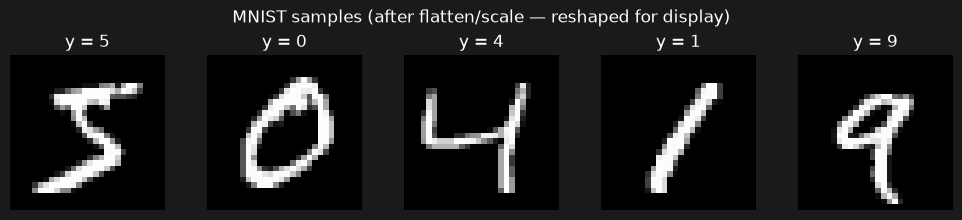

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2.2)) #显示前五张图片， fig整张大图，axes5个小图区域
for ax, i in zip(axes, range(5)): #循环前5个子图和前5张图片，ax是当前子图，i是图片编号，从0到4
    ax.imshow(x_train[i].reshape(28, 28), cmap="gray") #之前已经展开了，现在reshape为了展示
    ax.set_title(f"y = {y_train[i]}")
    ax.axis("off")
plt.suptitle("MNIST samples (after flatten/scale — reshaped for display)")
plt.tight_layout() #自动调整子图间距
plt.show()

## Step 2 — Baseline model (no dropout)

Softmax + `sparse_categorical_crossentropy` because labels are class indices. Evaluate on the test set once at the end — don’t peek repeatedly while tuning.

In [4]:
EPOCHS = 5
BATCH_SIZE = 128

model = keras.Sequential([ #sequential表示网络是一层一层堆叠起来的
    layers.Input(shape=(784,)), #每个样本长度是784的向量
    layers.Dense(128, activation="relu"), #全连接层128个神经元
    layers.Dense(10, activation="softmax"), #输出层，10类数字，0-9
])
model.compile(
    optimizer="adam", #常见的梯度下降的优化器
    loss="sparse_categorical_crossentropy", #使用稀疏类别交叉熵作为损失函数，是因为标签是整数，比如 3、7，不是 one-hot 向量。
    metrics=["accuracy"], #训练时额外记录准确率
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1, #从训练集中拿出10%作为验证集
    verbose=1, #显示训练进度条和每轮结果
)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Baseline test accuracy: {test_acc:.4f}  (target ~≥ 0.97 for this MLP)")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 971us/step - accuracy: 0.8934 - loss: 0.3867 - val_accuracy: 0.9547 - val_loss: 0.1702
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - accuracy: 0.9508 - loss: 0.1737 - val_accuracy: 0.9630 - val_loss: 0.1314
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - accuracy: 0.9643 - loss: 0.1230 - val_accuracy: 0.9670 - val_loss: 0.1104
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 879us/step - accuracy: 0.9727 - loss: 0.0955 - val_accuracy: 0.9760 - val_loss: 0.0923
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 866us/step - accuracy: 0.9776 - loss: 0.0775 - val_accuracy: 0.9760 - val_loss: 0.0829
Baseline test accuracy: 0.9729  (target ~≥ 0.97 for this MLP)


## Step 3 — Add dropout; compare curves

Dropout randomly zeros activations during training so features can’t co-adapt; Keras turns it off at `evaluate` / `predict`. Report **both** test accuracies honestly.

In [8]:
model_do = keras.Sequential([ #do通常用来表示dropout
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3), #随机30%的神经元输出设为0
    layers.Dense(10, activation="softmax"),
])
model_do.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_do = model_do.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1,
)

_, test_acc_do = model_do.evaluate(x_test, y_test, verbose=0) #这里用 _ 接收 loss，表示后面不关心这
print(f"Dropout test accuracy: {test_acc_do:.4f}")
print(f"Baseline vs dropout: {test_acc:.4f} vs {test_acc_do:.4f}")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8717 - loss: 0.4442 - val_accuracy: 0.9515 - val_loss: 0.1770
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - accuracy: 0.9359 - loss: 0.2225 - val_accuracy: 0.9653 - val_loss: 0.1287
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - accuracy: 0.9483 - loss: 0.1738 - val_accuracy: 0.9703 - val_loss: 0.1048
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step - accuracy: 0.9574 - loss: 0.1431 - val_accuracy: 0.9712 - val_loss: 0.0978
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step - accuracy: 0.9630 - loss: 0.1254 - val_accuracy: 0.9765 - val_loss: 0.0869
Dropout test accuracy: 0.9717
Baseline vs dropout: 0.9729 vs 0.9717


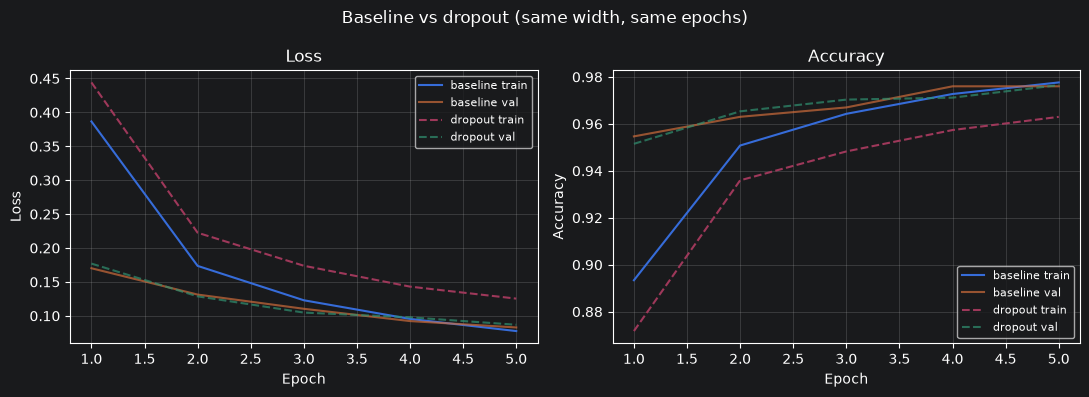

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4)) #创建一个图像窗口，包含1行2列的子图

for hist, label, style in [ #开始循环两个训练历史对象，label模型名称，style线条样式
    (history, "baseline", "-"),
    (history_do, "dropout", "--"),
]:
    epochs = range(1, len(hist.history["loss"]) + 1)
    axes[0].plot(epochs, hist.history["loss"], style, label=f"{label} train")
    axes[0].plot(epochs, hist.history["val_loss"], style, alpha=0.7, label=f"{label} val")
    axes[1].plot(epochs, hist.history["accuracy"], style, label=f"{label} train")
    axes[1].plot(epochs, hist.history["val_accuracy"], style, alpha=0.7, label=f"{label} val")

axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8) #添加图列
axes[0].grid(True, alpha=0.3) #添加网格线

axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Baseline vs dropout (same width, same epochs)")
plt.tight_layout()
plt.show()

## Step 4 — Confusion matrix → worst digit pair

Softmax returns 10 probabilities; the predicted class is `argmax`. In sklearn’s confusion matrix, rows = true labels and columns = predicted. The worst pair is the largest **off-diagonal** entry.

Use the dropout model here (or the baseline — note which). Assignment 2 asks for one worst pair from your chosen run.

Confusion matrix shape: (10, 10)


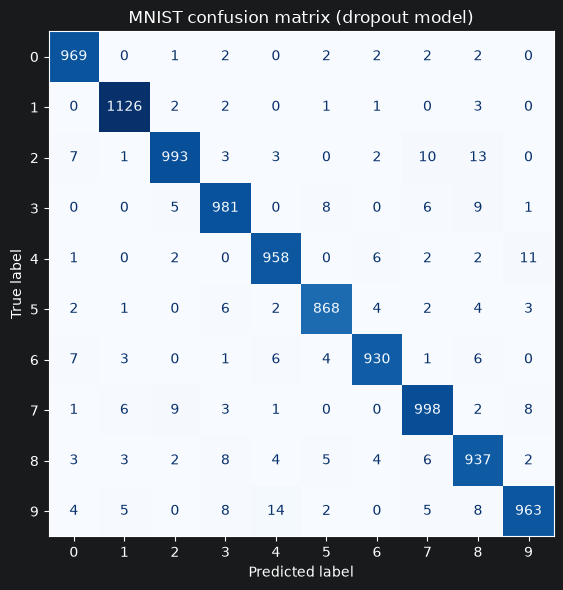

In [8]:
y_prob = model_do.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1) #把概率转换成预测类别 predicted class

cm = confusion_matrix(y_test, y_pred) #sklearn's confusion matrix
print("Confusion matrix shape:", cm.shape)

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False, cmap="Blues") #不显示颜色条，使用蓝色系配色
ax.set_title("MNIST confusion matrix (dropout model)")
plt.tight_layout()
plt.show()

In [9]:
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0) #把对角线设为0,这里要找“错误最多”的组合，所以先把正确预测排除掉。
true_digit, pred_digit = np.unravel_index(np.argmax(cm_off), cm_off.shape) #找出非对角线中最大的那个位置。np.argmax(cm_off)：找到最大值在展平数组中的索引; np.unravel_index(..., cm_off.shape)：把这个一维索引转换回二维坐标
n_confused = cm_off[true_digit, pred_digit] #取出这个最严重混淆组合出现的次数

print(
    f"Worst confused pair: true {true_digit} → predicted {pred_digit} "
    f"({n_confused} times)"
)
print("(Moodle a2_worst_pair style: e.g. '4/9' — true/predicted or unordered pair as specified)")

Worst confused pair: true 9 → predicted 4 (14 times)
(Moodle a2_worst_pair style: e.g. '4/9' — true/predicted or unordered pair as specified)


## Step 5 — Why `sparse_categorical_crossentropy`?

1. MNIST labels are **class indices** $0$–$9$, not length-10 one-hot vectors.
2. `sparse_categorical_crossentropy` expects those indices; `categorical_crossentropy` expects one-hot.
3. Same loss maths when encodings match — sparse is the natural fit here (no need to `to_categorical`).

**Trap:** Integer labels + `categorical_crossentropy` → shape/type error or nonsense training.

In [10]:
print("y_test sample (integers):", y_test[:5])
print("y_prob[0] (10 softmax probs):", np.round(y_prob[0], 3))
print("argmax → class", y_pred[0])

# Equivalent one-hot path (for discussion — we are NOT switching loss here)
y_test_oh = keras.utils.to_categorical(y_test, 10)
print("one-hot shape if we used categorical_crossentropy:", y_test_oh.shape)

y_test sample (integers): [7 2 1 0 4]
y_prob[0] (10 softmax probs): [0.    0.    0.    0.001 0.    0.    0.    0.999 0.    0.   ]
argmax → class 7
one-hot shape if we used categorical_crossentropy: (10000, 10)


## After class — Assignment 2

Due **end of Week 4**. Open `a2_mnist_classifier.ipynb` and replay this pipeline (architecture may differ — keep baseline vs dropout fair).

Moodle fields: `a2_test_acc`, `a2_test_acc_do`, `a2_worst_pair`, `a2_crossentropy`, repo, AI disclosure.

**Week 4 reading:** Chapters 5–6 (generalisation & universal workflow).